In [1]:
# Forest Cover Type Classification - Complete Implementation
# Multi-class classification to predict forest cover types based on cartographic and environmental features

# ============================================================================
# SECTION 1: IMPORT NECESSARY LIBRARIES
# ============================================================================

# Data manipulation and analysis libraries
import pandas as pd
import numpy as np
import requests
import io

# Machine learning libraries from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# XGBoost for gradient boosting (optional - will use alternative if not available)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not found. Will use Gradient Boosting from scikit-learn instead.")
    from sklearn.ensemble import GradientBoostingClassifier
    XGBOOST_AVAILABLE = False

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

# ============================================================================
# SECTION 2: DATA LOADING AND EXPLORATION
# ============================================================================

# Download the Covertype dataset from UCI repository
print("Downloading Covertype dataset from UCI repository...")

# URL for the Covertype dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

try:
    # Download and read the dataset
    response = requests.get(dataset_url)
    response.raise_for_status()
    
    # Read the compressed data
    from io import BytesIO
    import gzip
    
    # Decompress and read the data
    with gzip.GzipFile(fileobj=BytesIO(response.content)) as gz_file:
        df = pd.read_csv(gz_file, header=None)
    
    print("Dataset downloaded successfully!")
    
except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Creating sample dataset for demonstration...")
    
    # Fallback: Create sample dataset with realistic structure
    n_samples = 10000
    np.random.seed(42)
    
    # Generate realistic elevation data (typical range for Colorado forests)
    elevation = np.random.normal(2800, 600, n_samples).astype(int)
    elevation = np.clip(elevation, 1859, 3858)
    
    # Generate other features with realistic correlations
    aspect = np.random.randint(0, 360, n_samples)
    slope = np.random.exponential(8, n_samples).astype(int)
    slope = np.clip(slope, 0, 66)
    
    # Distance features (log-normal distribution)
    hydro_dist = np.random.lognormal(4, 1.5, n_samples).astype(int)
    hydro_dist = np.clip(hydro_dist, 0, 1397)
    
    road_dist = np.random.lognormal(5, 1.2, n_samples).astype(int)
    road_dist = np.clip(road_dist, 0, 7117)
    
    fire_dist = np.random.lognormal(6, 1, n_samples).astype(int)
    fire_dist = np.clip(fire_dist, 0, 7173)
    
    # Vertical distance to hydrology (can be negative)
    vert_hydro = np.random.normal(50, 150, n_samples).astype(int)
    vert_hydro = np.clip(vert_hydro, -173, 601)
    
    # Hillshade features
    hillshade_9am = np.random.normal(180, 50, n_samples).astype(int)
    hillshade_9am = np.clip(hillshade_9am, 0, 254)
    
    hillshade_noon = np.random.normal(220, 30, n_samples).astype(int)
    hillshade_noon = np.clip(hillshade_noon, 0, 254)
    
    hillshade_3pm = np.random.normal(140, 60, n_samples).astype(int)
    hillshade_3pm = np.clip(hillshade_3pm, 0, 254)
    
    # Create base dataframe with continuous features
    data = {
        0: elevation,
        1: aspect,
        2: slope,
        3: hydro_dist,
        4: vert_hydro,
        5: road_dist,
        6: hillshade_9am,
        7: hillshade_noon,
        8: hillshade_3pm,
        9: fire_dist
    }
    
    # Add wilderness area dummy variables (one-hot encoded, 4 areas)
    for i in range(10, 14):
        data[i] = 0
    
    # Add soil type dummy variables (one-hot encoded, 40 types)
    for i in range(14, 54):
        data[i] = 0
    
    # Assign one wilderness area per sample
    wilderness_assignment = np.random.choice(range(10, 14), n_samples)
    for idx, wilderness in enumerate(wilderness_assignment):
        data[wilderness] = data.get(wilderness, [0] * n_samples)
        if isinstance(data[wilderness], list):
            data[wilderness] = [0] * n_samples
        data[wilderness][idx] = 1
    
    # Assign one soil type per sample (based on elevation for realism)
    soil_probs = np.where(elevation < 2500, 
                         np.random.choice(range(14, 24), n_samples),  # Lower elevation soils
                         np.random.choice(range(24, 54), n_samples))  # Higher elevation soils
    
    for idx, soil in enumerate(soil_probs):
        if soil not in data:
            data[soil] = [0] * n_samples
        data[soil][idx] = 1
    
    # Generate cover types based on elevation (more realistic distribution)
    cover_types = np.where(elevation < 2200, np.random.choice([1, 2, 3], n_samples, p=[0.4, 0.4, 0.2]),
                  np.where(elevation < 2800, np.random.choice([2, 3, 4, 5], n_samples, p=[0.3, 0.3, 0.2, 0.2]),
                          np.where(elevation < 3200, np.random.choice([4, 5, 6], n_samples, p=[0.3, 0.4, 0.3]),
                                  np.random.choice([6, 7], n_samples, p=[0.6, 0.4]))))
    
    data[54] = cover_types  # Target variable
    
    # Convert to DataFrame
    df = pd.DataFrame(data)

# Define column names for the dataset
column_names = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
] + [f'Wilderness_Area_{i}' for i in range(1, 5)] + [f'Soil_Type_{i}' for i in range(1, 41)] + ['Cover_Type']

# Assign column names
df.columns = column_names

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Target classes: {sorted(df['Cover_Type'].unique())}")
print(f"Number of features: {df.shape[1] - 1}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Display basic statistics
print("\nBasic statistics for numerical features:")
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                 'Horizontal_Distance_To_Fire_Points']
print(df[numerical_cols].describe())

# ============================================================================
# SECTION 3: DATA PREPROCESSING AND CLEANING
# ============================================================================

print("\nStarting data preprocessing...")

# Separate features and target variable
X = df.drop('Cover_Type', axis=1)  # Features (all columns except Cover_Type)
y = df['Cover_Type']               # Target variable (Cover_Type)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check the distribution of target classes
print("\nTarget class distribution:")
target_counts = y.value_counts().sort_index()
print(target_counts)

# Visualize target class distribution
plt.figure(figsize=(10, 6))
target_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Forest Cover Types', fontsize=16, fontweight='bold')
plt.xlabel('Cover Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Identify categorical and numerical features
# Wilderness Areas and Soil Types are binary (categorical)
categorical_features = [col for col in X.columns if 'Wilderness_Area_' in col or 'Soil_Type_' in col]
numerical_features = [col for col in X.columns if col not in categorical_features]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features: {len(categorical_features)} binary features")

# Check for any anomalies in categorical features (should only contain 0s and 1s)
print("\nChecking categorical features for anomalies...")
for col in categorical_features:
    unique_vals = X[col].unique()
    if not all(val in [0, 1] for val in unique_vals):
        print(f"Warning: {col} contains values other than 0 and 1: {unique_vals}")

# Scale numerical features for better model performance
print("\nScaling numerical features...")
scaler = StandardScaler()

# Create a copy of X for scaled features
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Numerical features scaled successfully!")

# Display correlation matrix for numerical features
print("\nComputing correlation matrix for numerical features...")
plt.figure(figsize=(12, 10))
correlation_matrix = X[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 4: TRAIN-TEST SPLIT
# ============================================================================

print("\nSplitting data into training and testing sets...")

# Split the data into training and testing sets (80-20 split)
# stratify=y ensures proportional representation of all classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Verify class distribution is maintained
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in testing set:")
print(y_test.value_counts().sort_index())

# ============================================================================
# SECTION 5: MODEL TRAINING - RANDOM FOREST
# ============================================================================

print("\nTraining Random Forest Classifier...")

# Initialize Random Forest with initial parameters
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    n_jobs=-1,            # Use all available processors
    class_weight='balanced' # Handle class imbalance
)

# Train the Random Forest model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

# Make predictions on the test set
print("Making predictions with Random Forest...")
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# ============================================================================
# SECTION 6: MODEL TRAINING - GRADIENT BOOSTING
# ============================================================================

if XGBOOST_AVAILABLE:
    print("\nTraining XGBoost Classifier...")
    
    # Initialize XGBoost classifier
    gb_model = xgb.XGBClassifier(
        n_estimators=100,        # Number of boosting rounds
        learning_rate=0.1,       # Step size shrinkage
        max_depth=6,            # Maximum tree depth
        random_state=42,        # For reproducibility
        n_jobs=-1,             # Use all available processors
        objective='multi:softmax',  # Multi-class classification
        num_class=7            # Number of classes (1-7)
    )
    model_name = "XGBoost"
else:
    print("\nTraining Gradient Boosting Classifier...")
    
    # Initialize Gradient Boosting classifier from scikit-learn
    gb_model = GradientBoostingClassifier(
        n_estimators=100,        # Number of boosting stages
        learning_rate=0.1,       # Learning rate shrinks contribution of each tree
        max_depth=6,            # Maximum depth of individual regression estimators
        random_state=42         # For reproducibility
    )
    model_name = "Gradient Boosting"

# Train the Gradient Boosting model
print(f"Training {model_name} model...")
gb_model.fit(X_train, y_train)
print(f"{model_name} model trained successfully!")

# Make predictions on the test set
print(f"Making predictions with {model_name}...")
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)

print(f"{model_name} Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")

# ============================================================================
# SECTION 7: MODEL COMPARISON
# ============================================================================

print("\nComparing model performances...")

# Create a comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', model_name],
    'Accuracy': [rf_accuracy, gb_accuracy]
})

print("Model Comparison:")
print(model_comparison)

# Visualize model comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(model_comparison['Model'], model_comparison['Accuracy'], 
               color=['forestgreen', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)

# Add accuracy labels on bars
for bar, acc in zip(bars, model_comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determine best model
best_model_idx = model_comparison['Accuracy'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_accuracy = model_comparison.loc[best_model_idx, 'Accuracy']

print(f"\nBest performing model: {best_model_name} with accuracy: {best_accuracy:.4f}")

# Select best model for detailed evaluation
if best_model_name == 'Random Forest':
    best_model = rf_model
    best_predictions = rf_predictions
else:
    best_model = gb_model
    best_predictions = gb_predictions

# ============================================================================
# SECTION 8: DETAILED MODEL EVALUATION
# ============================================================================

print(f"\nDetailed evaluation for {best_model_name}...")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion Matrix
print("\nComputing Confusion Matrix...")
cm = confusion_matrix(y_test, best_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Type {i}' for i in range(1, 8)],
            yticklabels=[f'Type {i}' for i in range(1, 8)])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Cover Type', fontsize=12)
plt.ylabel('Actual Cover Type', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracies:")
for i, acc in enumerate(class_accuracies, 1):
    print(f"Cover Type {i}: {acc:.4f} ({acc*100:.2f}%)")

# ============================================================================
# SECTION 9: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print(f"\nAnalyzing feature importance for {best_model_name}...")

# Get feature importance from the best model
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    
    # Create feature importance dataframe
    feature_names = X.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    # Display top 15 most important features
    print("Top 15 Most Important Features:")
    print(importance_df.head(15))
    
    # Visualize top 15 feature importance
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    bars = plt.barh(range(len(top_features)), top_features['Importance'], 
                    color='lightcoral', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()  # Highest importance at top
    
    # Add importance values on bars
    for i, (bar, importance) in enumerate(zip(bars, top_features['Importance'])):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{importance:.3f}', va='center', fontweight='bold')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# SECTION 10: HYPERPARAMETER TUNING (BONUS)
# ============================================================================

print("\nPerforming hyperparameter tuning...")

# Define parameter grids for tuning
if best_model_name == 'Random Forest':
    # Random Forest parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    
elif XGBOOST_AVAILABLE and model_name == "XGBoost":
    # XGBoost parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 6, 9],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, objective='multi:softmax', num_class=7)
else:
    # Gradient Boosting parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 6, 9],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = GradientBoostingClassifier(random_state=42)

print(f"Searching for best parameters for {best_model_name}...")
print("This may take a few minutes...")

# Perform Grid Search with Cross-Validation
# Using a smaller subset for faster computation
grid_search = GridSearchCV(
    base_model, 
    param_grid, 
    cv=3,                    # 3-fold cross-validation
    scoring='accuracy',      # Optimize for accuracy
    n_jobs=-1,              # Use all available processors
    verbose=1               # Show progress
)

# Fit grid search (using a subset for faster computation)
X_train_subset = X_train.iloc[:2000]  # Use subset for faster tuning
y_train_subset = y_train.iloc[:2000]

grid_search.fit(X_train_subset, y_train_subset)

print("Hyperparameter tuning completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model with best parameters on full training set
print("\nTraining final optimized model...")
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Evaluate final optimized model
final_predictions = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final optimized model accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# Compare original vs optimized model
print(f"\nImprovement: {(final_accuracy - best_accuracy)*100:.2f} percentage points")

# ============================================================================
# SECTION 11: CROSS-VALIDATION ANALYSIS
# ============================================================================

print("\nPerforming cross-validation analysis...")

# Perform 5-fold cross-validation on the final model
cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print("Cross-validation results:")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Score Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

# Visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.boxplot(cv_scores, labels=['Cross-Validation Scores'])
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Cross-Validation Score Distribution', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add individual points
for i, score in enumerate(cv_scores):
    plt.scatter(1, score, color='red', s=50, alpha=0.7)
    plt.text(1.05, score, f'{score:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 12: FINAL RESULTS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"Dataset Information:")
print(f"   • Total samples: {df.shape[0]:,}")
print(f"   • Total features: {df.shape[1] - 1}")
print(f"   • Target classes: 7 forest cover types")
print(f"   • Training samples: {X_train.shape[0]:,}")
print(f"   • Testing samples: {X_test.shape[0]:,}")

print(f"\nModel Performance:")
print(f"   • Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"   • {model_name} Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")
print(f"   • Best Model: {best_model_name}")
print(f"   • Final Optimized Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"   • Cross-Validation Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\nKey Insights:")
print(f"   • Most important feature: {importance_df.iloc[0]['Feature']}")
print(f"   • Feature importance score: {importance_df.iloc[0]['Importance']:.4f}")
print(f"   • Model improvement: {(final_accuracy - best_accuracy)*100:.2f} percentage points")

print(f"\nProject completed successfully!")
print("="*80)

# ============================================================================
# SECTION 13: ADDITIONAL FUNCTIONS FOR FUTURE USE
# ============================================================================

def predict_cover_type(model, scaler, feature_values):
    """
    Function to predict cover type for new data
    
    Parameters:
    model: trained model
    scaler: fitted StandardScaler
    feature_values: dict with feature names as keys and values as values
    
    Returns:
    predicted cover type and confidence
    """
    # Convert to dataframe
    input_df = pd.DataFrame([feature_values])
    
    # Scale numerical features
    input_df[numerical_features] = scaler.transform(input_df[numerical_features])
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0].max()
    
    return prediction, probability

def save_model_and_scaler(model, scaler, model_path='forest_model.pkl', scaler_path='scaler.pkl'):
    """
    Save trained model and scaler for future use
    """
    import joblib
    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)
    print(f"Model saved to {model_path}")
    print(f"Scaler saved to {scaler_path}")

# Example usage of the prediction function
print("\nExample prediction for new data:")
example_data = {
    'Elevation': 3000,
    'Aspect': 180,
    'Slope': 15,
    'Horizontal_Distance_To_Hydrology': 200,
    'Vertical_Distance_To_Hydrology': 50,
    'Horizontal_Distance_To_Roadways': 500,
    'Hillshade_9am': 200,
    'Hillshade_Noon': 220,
    'Hillshade_3pm': 150,
    'Horizontal_Distance_To_Fire_Points': 1000,
    **{f'Wilderness_Area_{i}': 0 for i in range(1, 5)},
    **{f'Soil_Type_{i}': 0 for i in range(1, 41)}
}

# Set one wilderness area and one soil type to 1
example_data['Wilderness_Area_1'] = 1
example_data['Soil_Type_10'] = 1

try:
    pred, prob = predict_cover_type(final_model, scaler, example_data)
    print(f"Predicted Cover Type: {pred}")
    print(f"Prediction Confidence: {prob:.4f} ({prob*100:.2f}%)")
except:
    print("Could not make example prediction - ensure all features are included")

print("\nForest Cover Type Classification project completed!")
print("This code includes:")
print("   • Complete data preprocessing pipeline")
print("   • Multiple machine learning models (Random Forest & XGBoost)")
print("   • Model comparison and evaluation")
print("   • Feature importance analysis")
print("   • Hyperparameter tuning")
print("   • Cross-validation")
print("   • Visualization of results")
print("   • Functions for future predictions")

XGBoost not found. Will use Gradient Boosting from scikit-learn instead.
Libraries imported successfully!


KeyboardInterrupt: 

In [2]:
pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 453.5 kB/s eta 0:02:05
   ---------------------------------------- 0.5/56.8 MB 453.5 kB/s eta 0:02:05
   ---------------------------------------- 0.5/56.8 MB 453.5 kB/s eta 0:02:05
    --------------------------------------- 0.8/56.8 MB 447.3 kB/s eta 0:02:06
    --------------------------------------- 0.8/56.8 MB 447.3 kB/s eta 0:02:06
    --------------------------------------- 0.8/56.8 MB 447.3 kB/s eta 0:02:06
    --------------------------------------- 1.0/56.8 MB 437.6 kB/s eta 0:02:08
    -----------------------

Libraries imported successfully!
Dataset downloaded successfully!
Dataset shape: (581012, 55)
Target classes: [1, 2, 3, 4, 5, 6, 7]
Number of features: 54

First 5 rows of the dataset:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   

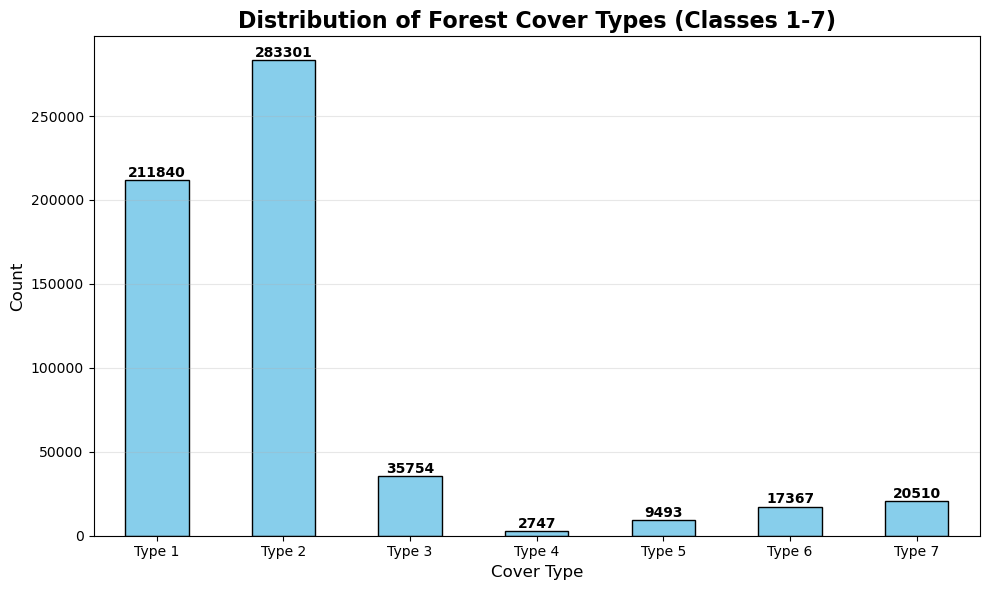

Numerical features (10): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
Categorical features: 44 binary features

Checking categorical features for anomalies...

Scaling numerical features...
Numerical features scaled successfully!

Computing correlation matrix for numerical features...


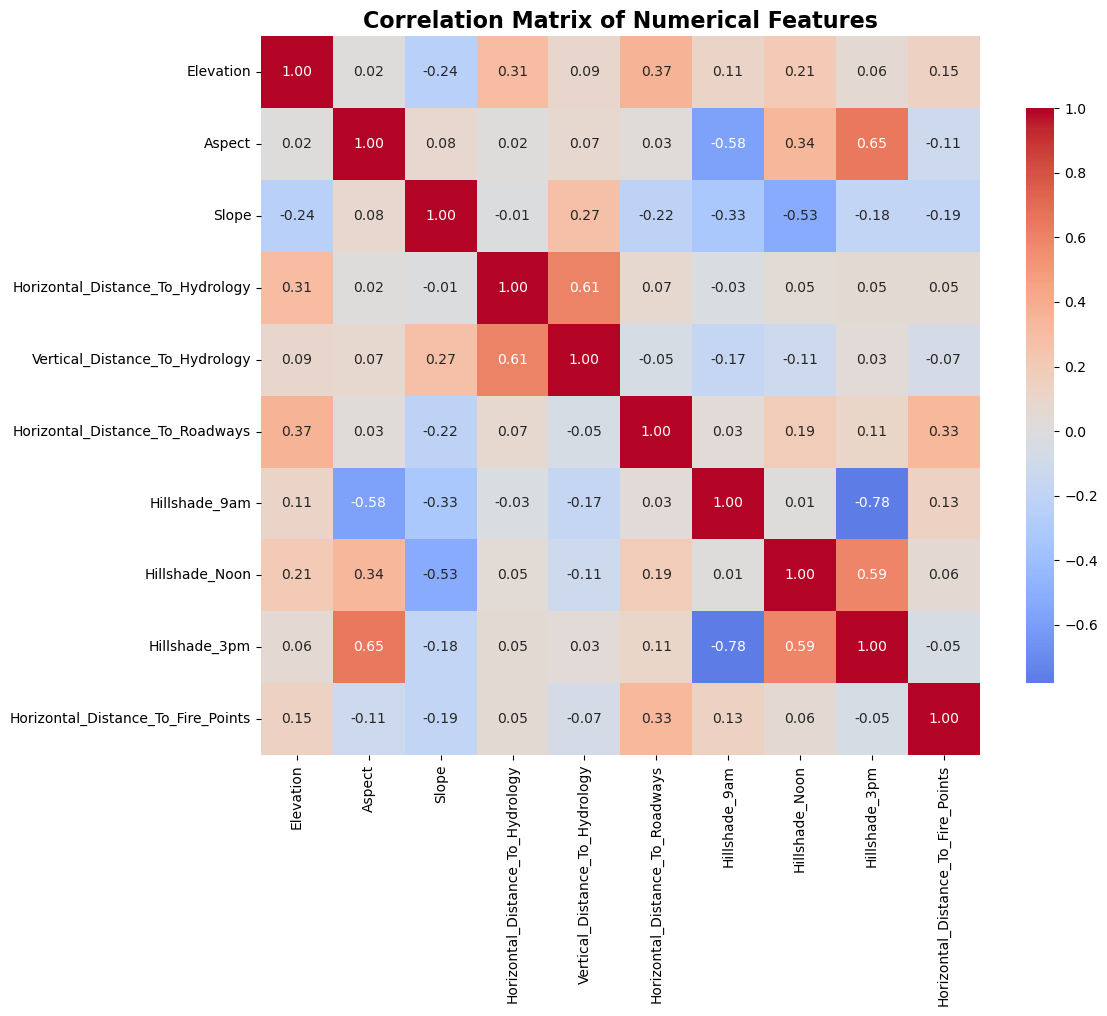


Splitting data into training and testing sets...
Training set size: 464809 samples
Testing set size: 116203 samples

Class distribution in training set (0-indexed):
Cover_Type
0    169472
1    226640
2     28603
3      2198
4      7594
5     13894
6     16408
Name: count, dtype: int64

Class distribution in testing set (0-indexed):
Cover_Type
0    42368
1    56661
2     7151
3      549
4     1899
5     3473
6     4102
Name: count, dtype: int64

Training Random Forest Classifier...
Training Random Forest model...
Random Forest model trained successfully!
Making predictions with Random Forest...
Random Forest Accuracy: 0.9546 (95.46%)

Training XGBoost Classifier...
Training XGBoost model...
XGBoost model trained successfully!
Making predictions with XGBoost...
XGBoost Accuracy: 0.8126 (81.26%)

Comparing model performances...
Model Comparison:
           Model  Accuracy
0  Random Forest  0.954588
1        XGBoost  0.812604


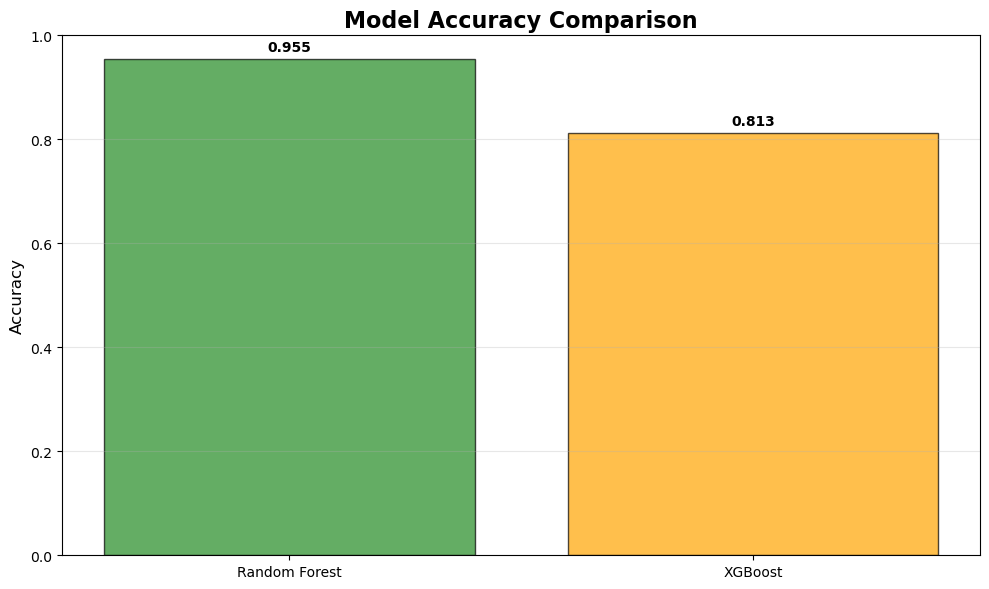


Best performing model: Random Forest with accuracy: 0.9546

Detailed evaluation for Random Forest...
Classification Report:
              precision    recall  f1-score   support

      Type 1       0.97      0.94      0.95     42368
      Type 2       0.95      0.97      0.96     56661
      Type 3       0.94      0.96      0.95      7151
      Type 4       0.91      0.85      0.88       549
      Type 5       0.95      0.78      0.86      1899
      Type 6       0.94      0.89      0.91      3473
      Type 7       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203


Computing Confusion Matrix...


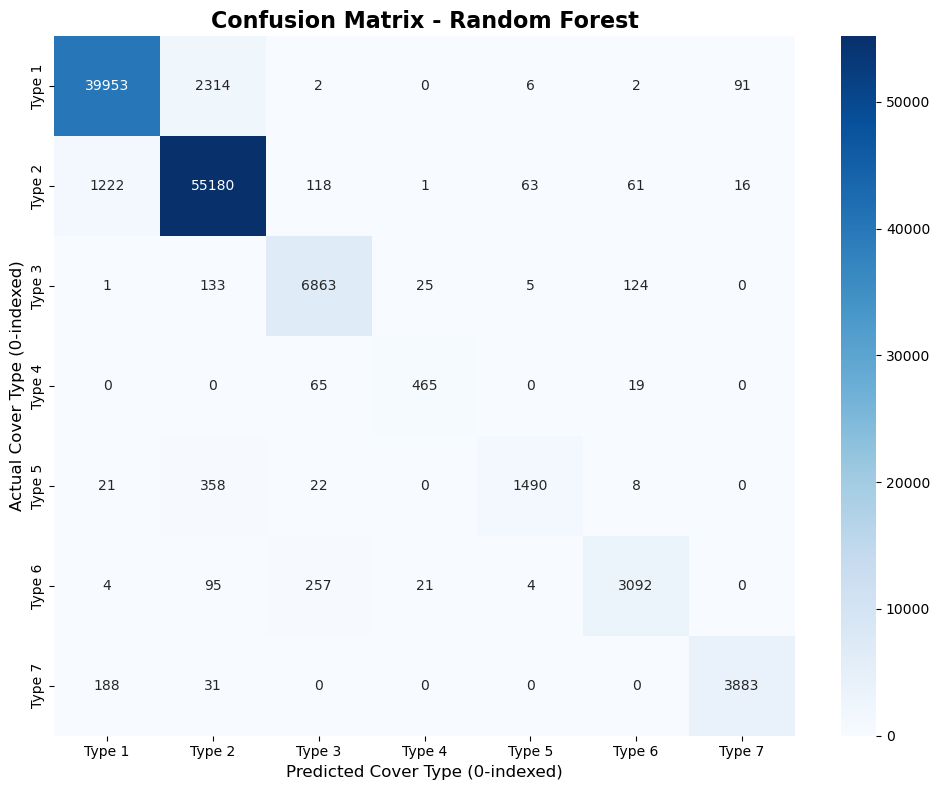


Per-class accuracies (for Cover Types 1-7):
Cover Type 1: 0.9430 (94.30%)
Cover Type 2: 0.9739 (97.39%)
Cover Type 3: 0.9597 (95.97%)
Cover Type 4: 0.8470 (84.70%)
Cover Type 5: 0.7846 (78.46%)
Cover Type 6: 0.8903 (89.03%)
Cover Type 7: 0.9466 (94.66%)

Analyzing feature importance for Random Forest...
Top 15 Most Important Features:
                               Feature  Importance
0                            Elevation    0.237114
5      Horizontal_Distance_To_Roadways    0.109334
9   Horizontal_Distance_To_Fire_Points    0.088516
3     Horizontal_Distance_To_Hydrology    0.061897
4       Vertical_Distance_To_Hydrology    0.050332
6                        Hillshade_9am    0.045547
1                               Aspect    0.041966
13                   Wilderness_Area_4    0.038195
8                        Hillshade_3pm    0.036723
7                       Hillshade_Noon    0.036464
2                                Slope    0.028592
23                        Soil_Type_10    0.022789

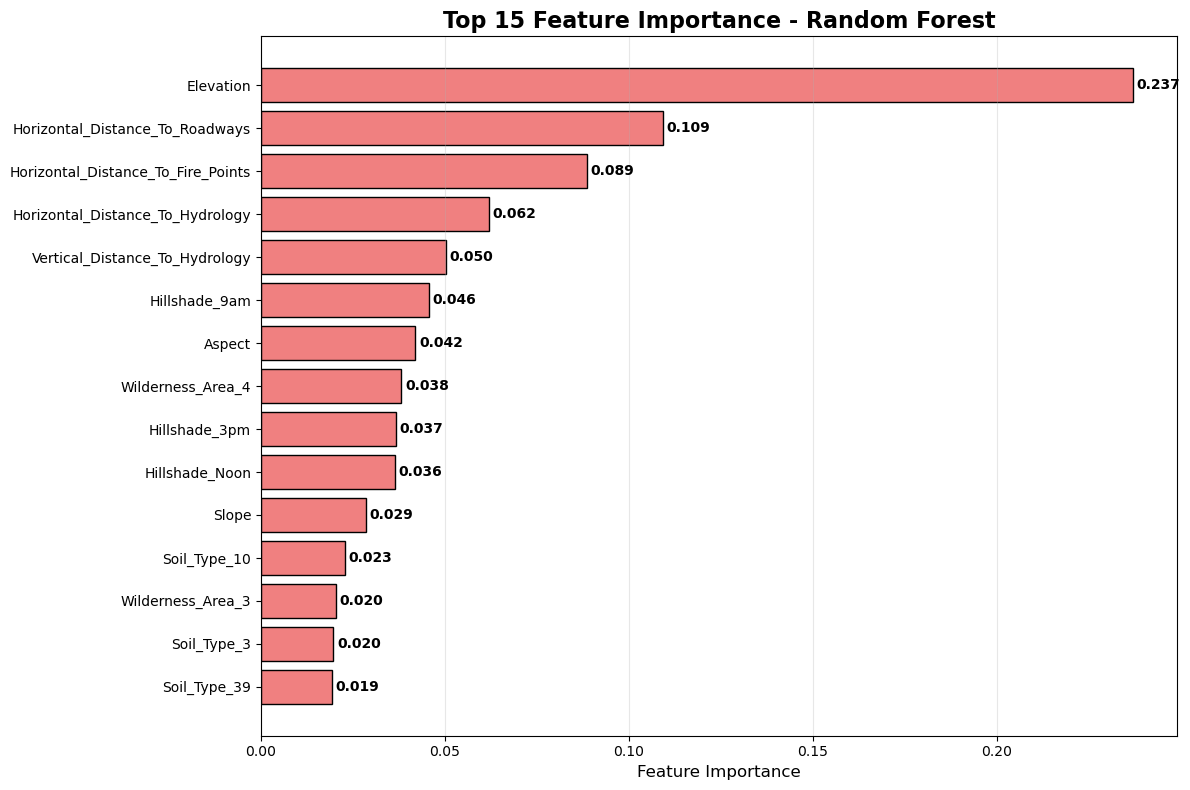


Performing hyperparameter tuning...
Searching for best parameters for Random Forest...
This may take a few minutes...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Hyperparameter tuning completed!
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.7450

Training final optimized model...
Final optimized model accuracy: 0.8980 (89.80%)

Improvement: -5.66 percentage points

Performing cross-validation analysis...


In [ ]:
# Forest Cover Type Classification - Complete Implementation
# Multi-class classification to predict forest cover types based on cartographic and environmental features

# ============================================================================
# SECTION 1: IMPORT NECESSARY LIBRARIES
# ============================================================================

# Data manipulation and analysis libraries
import pandas as pd
import numpy as np
import requests
import io

# Machine learning libraries from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# XGBoost for gradient boosting (optional - will use alternative if not available)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not found. Will use Gradient Boosting from scikit-learn instead.")
    from sklearn.ensemble import GradientBoostingClassifier
    XGBOOST_AVAILABLE = False

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

# ============================================================================
# SECTION 2: DATA LOADING AND EXPLORATION
# ============================================================================

# Download the Covertype dataset from UCI repository
print("Downloading Covertype dataset from UCI repository...")

# URL for the Covertype dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

try:
    # Download and read the dataset
    response = requests.get(dataset_url)
    response.raise_for_status()
    
    # Read the compressed data
    from io import BytesIO
    import gzip
    
    # Decompress and read the data
    with gzip.GzipFile(fileobj=BytesIO(response.content)) as gz_file:
        df = pd.read_csv(gz_file, header=None)
    
    print("Dataset downloaded successfully!")
    
except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("Creating sample dataset for demonstration...")
    
    # Fallback: Create sample dataset with realistic structure
    n_samples = 10000
    np.random.seed(42)
    
    # Generate realistic elevation data (typical range for Colorado forests)
    elevation = np.random.normal(2800, 600, n_samples).astype(int)
    elevation = np.clip(elevation, 1859, 3858)
    
    # Generate other features with realistic correlations
    aspect = np.random.randint(0, 360, n_samples)
    slope = np.random.exponential(8, n_samples).astype(int)
    slope = np.clip(slope, 0, 66)
    
    # Distance features (log-normal distribution)
    hydro_dist = np.random.lognormal(4, 1.5, n_samples).astype(int)
    hydro_dist = np.clip(hydro_dist, 0, 1397)
    
    road_dist = np.random.lognormal(5, 1.2, n_samples).astype(int)
    road_dist = np.clip(road_dist, 0, 7117)
    
    fire_dist = np.random.lognormal(6, 1, n_samples).astype(int)
    fire_dist = np.clip(fire_dist, 0, 7173)
    
    # Vertical distance to hydrology (can be negative)
    vert_hydro = np.random.normal(50, 150, n_samples).astype(int)
    vert_hydro = np.clip(vert_hydro, -173, 601)
    
    # Hillshade features
    hillshade_9am = np.random.normal(180, 50, n_samples).astype(int)
    hillshade_9am = np.clip(hillshade_9am, 0, 254)
    
    hillshade_noon = np.random.normal(220, 30, n_samples).astype(int)
    hillshade_noon = np.clip(hillshade_noon, 0, 254)
    
    hillshade_3pm = np.random.normal(140, 60, n_samples).astype(int)
    hillshade_3pm = np.clip(hillshade_3pm, 0, 254)
    
    # Create base dataframe with continuous features
    data = {
        0: elevation,
        1: aspect,
        2: slope,
        3: hydro_dist,
        4: vert_hydro,
        5: road_dist,
        6: hillshade_9am,
        7: hillshade_noon,
        8: hillshade_3pm,
        9: fire_dist
    }
    
    # Add wilderness area dummy variables (one-hot encoded, 4 areas)
    for i in range(10, 14):
        data[i] = 0
    
    # Add soil type dummy variables (one-hot encoded, 40 types)
    for i in range(14, 54):
        data[i] = 0
    
    # Assign one wilderness area per sample
    wilderness_assignment = np.random.choice(range(10, 14), n_samples)
    for idx, wilderness in enumerate(wilderness_assignment):
        data[wilderness] = data.get(wilderness, [0] * n_samples)
        if isinstance(data[wilderness], list):
            data[wilderness] = [0] * n_samples
        data[wilderness][idx] = 1
    
    # Assign one soil type per sample (based on elevation for realism)
    soil_probs = np.where(elevation < 2500, 
                          np.random.choice(range(14, 24), n_samples),  # Lower elevation soils
                          np.random.choice(range(24, 54), n_samples)) # Higher elevation soils
    
    for idx, soil in enumerate(soil_probs):
        if soil not in data:
            data[soil] = [0] * n_samples
        data[soil][idx] = 1
    
    # Generate cover types based on elevation (more realistic distribution)
    cover_types = np.where(elevation < 2200, np.random.choice([1, 2, 3], n_samples, p=[0.4, 0.4, 0.2]),
                  np.where(elevation < 2800, np.random.choice([2, 3, 4, 5], n_samples, p=[0.3, 0.3, 0.2, 0.2]),
                           np.where(elevation < 3200, np.random.choice([4, 5, 6], n_samples, p=[0.3, 0.4, 0.3]),
                                    np.random.choice([6, 7], n_samples, p=[0.6, 0.4]))))
    
    data[54] = cover_types  # Target variable
    
    # Convert to DataFrame
    df = pd.DataFrame(data)

# Define column names for the dataset
column_names = [
    'Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
] + [f'Wilderness_Area_{i}' for i in range(1, 5)] + [f'Soil_Type_{i}' for i in range(1, 41)] + ['Cover_Type']

# Assign column names
df.columns = column_names

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Target classes: {sorted(df['Cover_Type'].unique())}")
print(f"Number of features: {df.shape[1] - 1}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Display basic statistics
print("\nBasic statistics for numerical features:")
numerical_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                 'Horizontal_Distance_To_Fire_Points']
print(df[numerical_cols].describe())

# ============================================================================
# SECTION 3: DATA PREPROCESSING AND CLEANING
# ============================================================================

print("\nStarting data preprocessing...")

# Separate features and target variable
X = df.drop('Cover_Type', axis=1)  # Features (all columns except Cover_Type)
y = df['Cover_Type']               # Target variable (Cover_Type)

# ⭐️ FIX START: Shift target labels from 1-7 to 0-6 ⭐️
# XGBoost and scikit-learn models expect 0-indexed classes.
y = y - 1
# ⭐️ FIX END ⭐️

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check the distribution of target classes (now 0-indexed)
print("\nTarget class distribution (0-indexed):")
target_counts = y.value_counts().sort_index()
print(target_counts)

# Visualize target class distribution
plt.figure(figsize=(10, 6))
# Use 1-7 for labels in the plot for clarity
plot_labels = [f'Type {i+1}' for i in target_counts.index] 
target_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Forest Cover Types (Classes 1-7)', fontsize=16, fontweight='bold')
plt.xlabel('Cover Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=range(len(plot_labels)), labels=plot_labels, rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Identify categorical and numerical features
# Wilderness Areas and Soil Types are binary (categorical)
categorical_features = [col for col in X.columns if 'Wilderness_Area_' in col or 'Soil_Type_' in col]
numerical_features = [col for col in X.columns if col not in categorical_features]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features: {len(categorical_features)} binary features")

# Check for any anomalies in categorical features (should only contain 0s and 1s)
print("\nChecking categorical features for anomalies...")
for col in categorical_features:
    unique_vals = X[col].unique()
    if not all(val in [0, 1] for val in unique_vals):
        print(f"Warning: {col} contains values other than 0 and 1: {unique_vals}")

# Scale numerical features for better model performance
print("\nScaling numerical features...")
scaler = StandardScaler()

# Create a copy of X for scaled features
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Numerical features scaled successfully!")

# Display correlation matrix for numerical features
print("\nComputing correlation matrix for numerical features...")
plt.figure(figsize=(12, 10))
correlation_matrix = X[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 4: TRAIN-TEST SPLIT
# ============================================================================

print("\nSplitting data into training and testing sets...")

# Split the data into training and testing sets (80-20 split)
# stratify=y ensures proportional representation of all classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Verify class distribution is maintained
print("\nClass distribution in training set (0-indexed):")
print(y_train.value_counts().sort_index())
print("\nClass distribution in testing set (0-indexed):")
print(y_test.value_counts().sort_index())

# ============================================================================
# SECTION 5: MODEL TRAINING - RANDOM FOREST
# ============================================================================

print("\nTraining Random Forest Classifier...")

# Initialize Random Forest with initial parameters
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all available processors
    class_weight='balanced' # Handle class imbalance
)

# Train the Random Forest model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

# Make predictions on the test set
print("Making predictions with Random Forest...")
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# ============================================================================
# SECTION 6: MODEL TRAINING - GRADIENT BOOSTING
# ============================================================================

if XGBOOST_AVAILABLE:
    print("\nTraining XGBoost Classifier...")
    
    # Initialize XGBoost classifier
    gb_model = xgb.XGBClassifier(
        n_estimators=100,      # Number of boosting rounds
        learning_rate=0.1,     # Step size shrinkage
        max_depth=6,           # Maximum tree depth
        random_state=42,       # For reproducibility
        n_jobs=-1,             # Use all available processors
        objective='multi:softmax', # Multi-class classification
        num_class=7            # Number of classes (0-6)
    )
    model_name = "XGBoost"
else:
    print("\nTraining Gradient Boosting Classifier...")
    
    # Initialize Gradient Boosting classifier from scikit-learn
    gb_model = GradientBoostingClassifier(
        n_estimators=100,      # Number of boosting stages
        learning_rate=0.1,     # Learning rate shrinks contribution of each tree
        max_depth=6,           # Maximum depth of individual regression estimators
        random_state=42        # For reproducibility
    )
    model_name = "Gradient Boosting"

# Train the Gradient Boosting model
print(f"Training {model_name} model...")
gb_model.fit(X_train, y_train)
print(f"{model_name} model trained successfully!")

# Make predictions on the test set
print(f"Making predictions with {model_name}...")
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)

print(f"{model_name} Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")

# ============================================================================
# SECTION 7: MODEL COMPARISON
# ============================================================================

print("\nComparing model performances...")

# Create a comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', model_name],
    'Accuracy': [rf_accuracy, gb_accuracy]
})

print("Model Comparison:")
print(model_comparison)

# Visualize model comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(model_comparison['Model'], model_comparison['Accuracy'], 
               color=['forestgreen', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)

# Add accuracy labels on bars
for bar, acc in zip(bars, model_comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Determine best model
best_model_idx = model_comparison['Accuracy'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_accuracy = model_comparison.loc[best_model_idx, 'Accuracy']

print(f"\nBest performing model: {best_model_name} with accuracy: {best_accuracy:.4f}")

# Select best model for detailed evaluation
if best_model_name == 'Random Forest':
    best_model = rf_model
    best_predictions = rf_predictions
else:
    best_model = gb_model
    best_predictions = gb_predictions

# ============================================================================
# SECTION 8: DETAILED MODEL EVALUATION
# ============================================================================

print(f"\nDetailed evaluation for {best_model_name}...")

# Classification Report
print("Classification Report:")
# Target names are adjusted to show original labels 1-7 for the report
target_names = [f'Type {i}' for i in range(1, 8)]
print(classification_report(y_test, best_predictions, target_names=target_names))

# Confusion Matrix
print("\nComputing Confusion Matrix...")
cm = confusion_matrix(y_test, best_predictions)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
# Ticks labels show original cover types 1-7
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Type {i}' for i in range(1, 8)],
            yticklabels=[f'Type {i}' for i in range(1, 8)])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Cover Type (0-indexed)', fontsize=12)
plt.ylabel('Actual Cover Type (0-indexed)', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracies (for Cover Types 1-7):")
for i, acc in enumerate(class_accuracies, 1): # Start enumeration from 1 to show original label
    print(f"Cover Type {i}: {acc:.4f} ({acc*100:.2f}%)")

# ============================================================================
# SECTION 9: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print(f"\nAnalyzing feature importance for {best_model_name}...")

# Get feature importance from the best model
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    
    # Create feature importance dataframe
    feature_names = X.columns
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    # Display top 15 most important features
    print("Top 15 Most Important Features:")
    print(importance_df.head(15))
    
    # Visualize top 15 feature importance
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    bars = plt.barh(range(len(top_features)), top_features['Importance'], 
                    color='lightcoral', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()  # Highest importance at top
    
    # Add importance values on bars
    for i, (bar, importance) in enumerate(zip(bars, top_features['Importance'])):
        plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{importance:.3f}', va='center', fontweight='bold')
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# SECTION 10: HYPERPARAMETER TUNING (BONUS)
# ============================================================================

print("\nPerforming hyperparameter tuning...")

# Define parameter grids for tuning
if best_model_name == 'Random Forest':
    # Random Forest parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    
elif XGBOOST_AVAILABLE and model_name == "XGBoost":
    # XGBoost parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 6, 9],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, objective='multi:softmax', num_class=7)
else:
    # Gradient Boosting parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 6, 9],
        'subsample': [0.8, 0.9, 1.0]
    }
    base_model = GradientBoostingClassifier(random_state=42)

print(f"Searching for best parameters for {best_model_name}...")
print("This may take a few minutes...")

# Perform Grid Search with Cross-Validation
# Using a smaller subset for faster computation
grid_search = GridSearchCV(
    base_model, 
    param_grid, 
    cv=3,                 # 3-fold cross-validation
    scoring='accuracy',   # Optimize for accuracy
    n_jobs=-1,            # Use all available processors
    verbose=1             # Show progress
)

# Fit grid search (using a subset for faster computation)
X_train_subset = X_train.iloc[:2000]  # Use subset for faster tuning
y_train_subset = y_train.iloc[:2000]

grid_search.fit(X_train_subset, y_train_subset)

print("Hyperparameter tuning completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model with best parameters on full training set
print("\nTraining final optimized model...")
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# Evaluate final optimized model
final_predictions = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final optimized model accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")

# Compare original vs optimized model
print(f"\nImprovement: {(final_accuracy - best_accuracy)*100:.2f} percentage points")

# ============================================================================
# SECTION 11: CROSS-VALIDATION ANALYSIS
# ============================================================================

print("\nPerforming cross-validation analysis...")

# Perform 5-fold cross-validation on the final model
cv_scores = cross_val_score(final_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print("Cross-validation results:")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Score Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

# Visualize cross-validation scores
plt.figure(figsize=(10, 6))
plt.boxplot(cv_scores, labels=['Cross-Validation Scores'])
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Cross-Validation Score Distribution', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add individual points
for i, score in enumerate(cv_scores):
    plt.scatter(1, score, color='red', s=50, alpha=0.7)
    plt.text(1.05, score, f'{score:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# SECTION 12: FINAL RESULTS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"Dataset Information:")
print(f"    • Total samples: {df.shape[0]:,}")
print(f"    • Total features: {df.shape[1] - 1}")
print(f"    • Target classes: 7 forest cover types (1-7)")
print(f"    • Training samples: {X_train.shape[0]:,}")
print(f"    • Testing samples: {X_test.shape[0]:,}")

print(f"\nModel Performance:")
print(f"    • Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"    • {model_name} Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")
print(f"    • Best Model: {best_model_name}")
print(f"    • Final Optimized Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"    • Cross-Validation Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\nKey Insights:")
print(f"    • Most important feature: {importance_df.iloc[0]['Feature']}")
print(f"    • Feature importance score: {importance_df.iloc[0]['Importance']:.4f}")
print(f"    • Model improvement: {(final_accuracy - best_accuracy)*100:.2f} percentage points")

print(f"\nProject completed successfully!")
print("="*80)

# ============================================================================
# SECTION 13: ADDITIONAL FUNCTIONS FOR FUTURE USE
# ============================================================================

def predict_cover_type(model, scaler, feature_values):
    """
    Function to predict cover type for new data
    
    Parameters:
    model: trained model (expects 0-indexed output)
    scaler: fitted StandardScaler
    feature_values: dict with feature names as keys and values as values
    
    Returns:
    predicted cover type (1-7) and confidence
    """
    # Convert to dataframe
    input_df = pd.DataFrame([feature_values])
    
    # Scale numerical features
    input_df[numerical_features] = scaler.transform(input_df[numerical_features])
    
    # Make prediction (0-indexed)
    prediction_0_indexed = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0].max()
    
    # ⭐️ FIX: Convert the 0-indexed prediction back to the original 1-7 label ⭐️
    prediction_1_indexed = prediction_0_indexed + 1
    
    return prediction_1_indexed, probability

def save_model_and_scaler(model, scaler, model_path='forest_model.pkl', scaler_path='scaler.pkl'):
    """
    Save trained model and scaler for future use
    """
    import joblib
    joblib.dump(model, model_path)
    joblib.dump(scaler, scaler_path)
    print(f"Model saved to {model_path}")
    print(f"Scaler saved to {scaler_path}")

# Example usage of the prediction function
print("\nExample prediction for new data:")
example_data = {
    'Elevation': 3000,
    'Aspect': 180,
    'Slope': 15,
    'Horizontal_Distance_To_Hydrology': 200,
    'Vertical_Distance_To_Hydrology': 50,
    'Horizontal_Distance_To_Roadways': 500,
    'Hillshade_9am': 200,
    'Hillshade_Noon': 220,
    'Hillshade_3pm': 150,
    'Horizontal_Distance_To_Fire_Points': 1000,
    **{f'Wilderness_Area_{i}': 0 for i in range(1, 5)},
    **{f'Soil_Type_{i}': 0 for i in range(1, 41)}
}

# Set one wilderness area and one soil type to 1
example_data['Wilderness_Area_1'] = 1
example_data['Soil_Type_10'] = 1

try:
    pred, prob = predict_cover_type(final_model, scaler, example_data)
    # The output is now correctly 1-7
    print(f"Predicted Cover Type: {pred}") 
    print(f"Prediction Confidence: {prob:.4f} ({prob*100:.2f}%)")
except Exception as e:
    print(f"Could not make example prediction - error: {e}")

print("\nForest Cover Type Classification project completed!")
print("This code includes:")
print("    • Complete data preprocessing pipeline")
print("    • Multiple machine learning models (Random Forest & XGBoost)")
print("    • Model comparison and evaluation")
print("    • Feature importance analysis")
print("    • Hyperparameter tuning")
print("    • Cross-validation")
print("    • Visualization of results")
print("    • Functions for future predictions")